In [179]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option("display.max_rows", None)

pd.set_option("display.max_columns", None)


In [180]:
df = pd.read_csv(r"C:\Users\DELL\Desktop\Data\Airbnb+Data\Airbnb Data\Listings.csv", encoding="latin-1",low_memory=False)


In [181]:
reviews=pd.read_csv(r"C:\Users\DELL\Desktop\Data\Airbnb+Data\Airbnb Data\Reviews.csv")

In [182]:
reviews_count = reviews.groupby("listing_id")["review_id"].count().reset_index()
reviews_count.columns = ["listing_id", "number_of_reviews"]
df = df.merge(reviews_count, on="listing_id", how="left")

df["number_of_reviews"] = df["number_of_reviews"].fillna(0)
df["number_of_reviews"] = df["number_of_reviews"].astype('int')

In [183]:
df.head(5)
df.shape
# df.columns

(279712, 34)

In [184]:
pd.set_option("display.max_rows", None)
df.isna().sum().reset_index()

,index,0
0,listing_id,0
1,name,175
2,host_id,0
3,host_since,165
4,host_location,840
5,host_response_time,128782
6,host_response_rate,128782
7,host_acceptance_rate,113087
8,host_is_superhost,165
9,host_total_listings_count,165


In [185]:
df.dtypes
df[df["host_id"]==1466919]
df[df["bedrooms"].isna()]["room_type"].describe()
# df["host_response_rate"].describe()
# df["host_acceptance_rate"].describe()
df[["district","neighbourhood"]].head(35)
df["host_id"].nunique()

182024

In [186]:
df = df.drop_duplicates()
df.shape
df = df.dropna(subset=[
    "host_is_superhost",
    "host_total_listings_count",
    "host_has_profile_pic",
    "host_identity_verified"
])
# df=df.drop(columns=["district","name","longitude","latitude"])
df=df.drop(columns=["host_location"])

In [187]:
# df.groupby(["property_type"])["bedrooms"].count().reset_index()
# df[(df["bedrooms"].isna())&(df["property_type"]!="Entire apartment")][["property_type","bedrooms"]].head(50)
# df["bedrooms"].describe()
# df.groupby("room_type")["bedrooms"].describe()
# m=df[df["room_type"]=="Hotel room"][["property_type","room_type","bedrooms","accommodates"]].head(30)
# m.sort_values(by="bedrooms",ascending=False).head()
# # df["room_type"].value_counts()

In [188]:


df[df["bedrooms"].isna()]["accommodates"].describe()
# df[(df["accommodates"]==16)&(df["room_type"]=="Hotel room")][["property_type","room_type","bedrooms","accommodates","price"]]
# df[df["bedrooms"]>df["accommodates"]][["property_type","room_type","bedrooms","accommodates"]].sort_values(by="bedrooms",ascending=False)

count    29415.000000
mean         2.336529
std          1.175463
min          0.000000
25%          2.000000
50%          2.000000
75%          2.000000
max         16.000000
Name: accommodates, dtype: float64

In [189]:
df["property_type"].nunique()
df[["room_detail", "base_type"]] = df["property_type"].str.split(" in ", expand=True)
df[df["base_type"].isna()]["room_detail"]
df["base_type"]=df["base_type"].fillna(df["room_detail"])
df["base_type"] = df["base_type"].str.replace("Entire ", "", regex=False)


In [190]:
df["base_type"].value_counts()
df["base_type"].nunique()

80

In [191]:
df[df["accommodates"]==2]["base_type"].value_counts()

base_type
apartment             78797
house                  9179
condominium            6741
boutique hotel         3722
bed and breakfast      3426
serviced apartment     2683
loft                   2409
guest suite            2327
hotel                  2016
townhouse              2003
guesthouse             1418
hostel                  889
aparthotel              747
villa                   362
Private room            302
cottage                 197
Tiny house              163
bungalow                127
place                   114
tiny house               86
cabin                    73
home/apt                 53
casa particular          42
chalet                   35
farm stay                34
nature lodge             33
resort                   25
earth house              24
Camper/RV                19
Farm stay                19
Boat                     18
Casa particular          14
kezhan                   14
dome house               12
boat                     11
hut       

In [192]:
df[df["price"]==0].count()
df[df["price"]==0]["bedrooms"].describe()
df[df["price"]==0].head(10)

,listing_id,name,host_id,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood,district,city,latitude,longitude,property_type,room_type,accommodates,bedrooms,amenities,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,number_of_reviews,room_detail,base_type
98209,44312919,Bienvenue ÃÂ l'HÃÂ´tel des 3 CollÃÂ¨ges,357400186,2020-07-20,NaN,NaN,NaN,f,0.0,t,t,Pantheon,NaN,Paris,48.848020,2.342340,Room in boutique hotel,Hotel room,0,NaN,"[""Free wifi"", ""Building staff"", ""Complimentary...",0,1,1125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f,0,Room,boutique hotel
202022,42830099,Hotel Hugo,300800542,2019-10-07,within an hour,1.0,1.0,f,9.0,t,t,SoHo,Manhattan,New York,40.726380,-74.008850,Room in boutique hotel,Hotel room,0,NaN,"[""Keurig coffee machine"", ""Pack \u2019n Play/t...",0,30,365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f,0,Room,boutique hotel
202023,43247472,Hotel 57,324955773,2020-01-06,within an hour,1.0,1.0,f,4.0,t,t,Midtown,Manhattan,New York,40.760850,-73.969380,Room in boutique hotel,Hotel room,0,NaN,"[""Air conditioning"", ""Coffee maker"", ""Concierg...",0,30,365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f,0,Room,boutique hotel
203253,43205598,Wellington Hotel,335389657,2020-02-11,within an hour,1.0,1.0,f,0.0,t,t,Midtown,Manhattan,New York,40.764480,-73.980550,Room in boutique hotel,Hotel room,0,NaN,"[""Self-parking \u2014 $45/day"", ""Hot breakfast...",0,1,365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f,0,Room,boutique hotel
203254,44567521,"The Standard, East Village",360662584,2020-08-05,within an hour,1.0,1.0,f,0.0,t,f,East Village,Manhattan,New York,40.727430,-73.991360,Room in boutique hotel,Hotel room,0,NaN,"[""HDTV"", "" linens"", ""Dedicated workspace"", ""He...",0,1,365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f,0,Room,boutique hotel
203255,45985185,Hotel Scherman,372762243,2020-10-21,within an hour,1.0,1.0,f,7.0,t,t,Hell's Kitchen,Manhattan,New York,40.761331,-73.989026,Room in boutique hotel,Hotel room,0,NaN,"[""50\"" HDTV with premium cable"", ""Kitchenette""...",0,1,365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f,0,Room,boutique hotel
203256,46251446,citizenM New York Bowery,374516933,2020-11-05,within an hour,1.0,1.0,f,0.0,t,t,Lower East Side,Manhattan,New York,40.719732,-73.993996,Room in boutique hotel,Hotel room,0,NaN,"["" toiletries"", ""Building staff"", ""Air conditi...",0,1,365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f,0,Room,boutique hotel
203257,43012882,Timhotel Paris Berthier,333365314,2020-02-04,within an hour,1.0,1.0,f,0.0,t,t,Batignolles-Monceau,NaN,Paris,48.894430,2.312450,Room in hotel,Hotel room,0,NaN,"[""Bed sheets and pillows"", ""Patio or balcony"",...",0,1,365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f,0,Room,hotel
203258,43035744,Le Pigalle,100008960,2016-10-17,within an hour,1.0,1.0,f,7.0,t,t,Opera,NaN,Paris,48.881620,2.337180,Room in boutique hotel,Hotel room,0,NaN,"[""Bed sheets and pillows"", ""Concierge"", ""Self-...",0,1,365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f,0,Room,boutique hotel
203259,43274767,Hotel MAYET,344545473,2020-04-24,within an hour,1.0,1.0,f,0.0,t,f,Luxembourg,NaN,Paris,48.847160,2.318620,Room in boutique hotel,Hotel room,0,NaN,"[""Free wifi"", ""Limited housekeeping \u2014 wee...",0,1,365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f,0,Room,boutique hotel


Drop listing where price is Zero


In [193]:
df = df[df["price"] > 0]
df.shape

(279434, 35)

Price outliers

In [194]:
df=df[df["price"] < df["price"].quantile(0.999)]
df=df[df["price"]>15]



In [195]:
df["city"].value_counts()

city
Paris             64525
New York          36955
Sydney            33584
Rome              27417
Rio de Janeiro    26539
Istanbul          24478
Mexico City       20021
Bangkok           19265
Cape Town         18984
Hong Kong          7079
Name: count, dtype: int64

paris listing only

In [196]:
df=df[df["city"]=="Paris"]

In [197]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 64525 entries, 0 to 279711
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   listing_id                   64525 non-null  int64  
 1   name                         64462 non-null  object 
 2   host_id                      64525 non-null  int64  
 3   host_since                   64525 non-null  object 
 4   host_response_time           23308 non-null  object 
 5   host_response_rate           23308 non-null  float64
 6   host_acceptance_rate         31866 non-null  float64
 7   host_is_superhost            64525 non-null  object 
 8   host_total_listings_count    64525 non-null  float64
 9   host_has_profile_pic         64525 non-null  object 
 10  host_identity_verified       64525 non-null  object 
 11  neighbourhood                64525 non-null  object 
 12  district                     0 non-null      object 
 13  city                

Drop district column

In [198]:
df=df.drop(columns="district")

In [199]:
df["bedrooms"].value_counts()

bedrooms
1.0     37783
2.0      9607
3.0      2891
4.0       720
5.0       149
6.0        35
7.0         9
50.0        7
23.0        2
33.0        2
31.0        1
38.0        1
12.0        1
9.0         1
Name: count, dtype: int64

In [200]:
df[df["bedrooms"]>10].count()
# df[df["property_type"]=="Room in boutique hotel"][["property_type","bedrooms","accommodates"]]

listing_id                     14
name                           14
host_id                        14
host_since                     14
host_response_time             13
host_response_rate             13
host_acceptance_rate           12
host_is_superhost              14
host_total_listings_count      14
host_has_profile_pic           14
host_identity_verified         14
neighbourhood                  14
city                           14
latitude                       14
longitude                      14
property_type                  14
room_type                      14
accommodates                   14
bedrooms                       14
amenities                      14
price                          14
minimum_nights                 14
maximum_nights                 14
review_scores_rating            9
review_scores_accuracy          9
review_scores_cleanliness       9
review_scores_checkin           9
review_scores_communication     9
review_scores_location          9
review_scores_

drop not logical bedrooms

In [201]:
df=df[df["bedrooms"] < 10]
df.shape

(51195, 34)

Fill nulls in bedrooms column

In [202]:
df["bedrooms"]=df["bedrooms"].fillna(df.groupby(["property_type","accommodates"])["bedrooms"].transform("median"))

In [203]:
df.dtypes.reset_index()

,index,0
0,listing_id,int64
1,name,object
2,host_id,int64
3,host_since,object
4,host_response_time,object
5,host_response_rate,float64
6,host_acceptance_rate,float64
7,host_is_superhost,object
8,host_total_listings_count,float64
9,host_has_profile_pic,object


Drop columns

In [204]:
df=df.drop(columns=["latitude","longitude","city","name","room_detail"])

Change datatypes

In [205]:
df["bedrooms"]=df["bedrooms"].astype('int')
df["price"]=df["price"].astype('int')

In [206]:
df["amenities"].head(3)
# df["neighbourhood"].value_counts()

0    ["Heating", "Kitchen", "Washer", "Wifi", "Long...
1    ["Shampoo", "Heating", "Kitchen", "Essentials"...
2    ["Heating", "TV", "Kitchen", "Washer", "Wifi",...
Name: amenities, dtype: object

Location Analysis

In [207]:
df["neighbourhood"].value_counts()

neighbourhood
Buttes-Montmartre      5866
Popincourt             4835
Enclos-St-Laurent      3738
Vaugirard              3717
Batignolles-Monceau    3418
Buttes-Chaumont        3077
Menilmontant           3032
Opera                  2547
Passy                  2443
Temple                 2279
Reuilly                2113
Observatoire           1978
Gobelins               1811
Bourse                 1705
Pantheon               1651
Luxembourg             1560
Hotel-de-Ville         1524
Elysee                 1429
Palais-Bourbon         1364
Louvre                 1108
Name: count, dtype: int64

In [208]:
top10 = df["neighbourhood"].value_counts().head(10)

top10 = top10.sort_values(ascending=True)  # عشان الشكل يطلع حلو

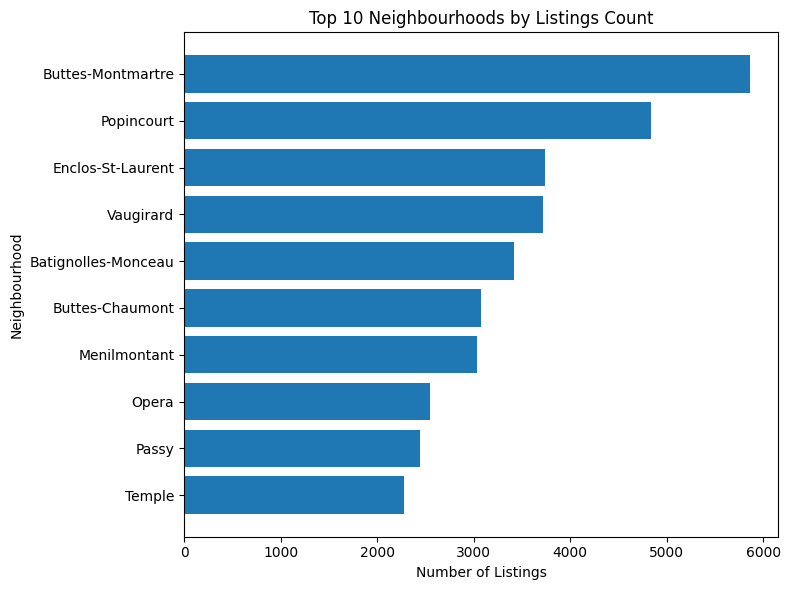

In [209]:
plt.figure(figsize=(8,6))
plt.barh(top10.index, top10.values)

plt.title("Top 10 Neighbourhoods by Listings Count")
plt.xlabel("Number of Listings")
plt.ylabel("Neighbourhood")

plt.tight_layout()
plt.show()

In [210]:
df.groupby("neighbourhood")["price"].agg(['median','mean','min','max','count']).reset_index().sort_values(by='median',ascending=False).head(10)

,neighbourhood,median,mean,min,max,count
4,Elysee,150.0,237.616515,16,8000,1429
8,Louvre,130.0,190.472022,24,8000,1108
9,Luxembourg,125.0,176.138462,20,2299,1560
13,Palais-Bourbon,123.5,179.678152,16,3876,1364
7,Hotel-de-Ville,120.0,162.345144,20,5000,1524
15,Passy,119.0,188.650020,18,10250,2443
1,Bourse,115.0,169.444575,19,2400,1705
18,Temple,111.0,155.528741,20,9631,2279
14,Pantheon,108.0,137.671108,20,4000,1651
12,Opera,100.0,131.423243,21,9280,2547


High demand locations

In [211]:
df.groupby("neighbourhood")["number_of_reviews"].sum()

neighbourhood
Batignolles-Monceau    46389
Bourse                 47615
Buttes-Chaumont        43444
Buttes-Montmartre      98209
Elysee                 28300
Enclos-St-Laurent      76940
Gobelins               31162
Hotel-de-Ville         42845
Louvre                 30093
Luxembourg             39446
Menilmontant           42549
Observatoire           33892
Opera                  49551
Palais-Bourbon         30046
Pantheon               40778
Passy                  35874
Popincourt             88563
Reuilly                37888
Temple                 61133
Vaugirard              69443
Name: number_of_reviews, dtype: int32

In [212]:
df["number_of_reviews"].value_counts()

number_of_reviews
0      12281
1       5008
2       3263
3       2549
4       2079
5       1773
6       1494
7       1306
8       1193
9       1035
10       986
11       844
12       816
13       709
14       655
15       630
17       583
16       564
18       487
20       481
19       477
21       429
22       399
23       378
24       375
25       340
26       321
27       312
30       304
28       293
31       257
32       241
29       220
33       214
35       200
39       199
34       195
37       193
36       190
40       180
38       178
41       162
43       153
42       149
51       148
44       147
47       144
50       140
45       139
48       116
49       114
52       113
46       111
54       111
55       103
53       100
58        99
56        95
57        95
60        95
62        87
63        85
59        84
61        81
66        81
68        77
73        71
67        68
84        67
65        64
70        60
85        58
77        58
64        58
74        56
69     

In [213]:
df["number_of_reviews"].describe()

count    51195.000000
mean        19.028421
std         40.608374
min          0.000000
25%          1.000000
50%          5.000000
75%         19.000000
max        891.000000
Name: number_of_reviews, dtype: float64

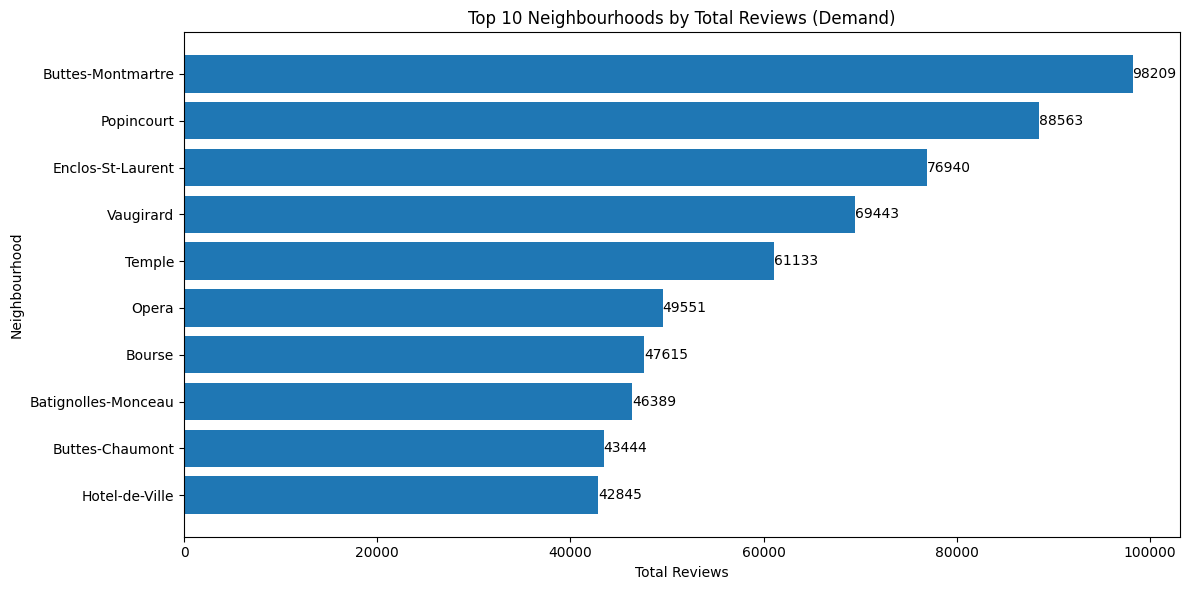

In [214]:
demand = df.groupby("neighbourhood")["number_of_reviews"].sum()

# نجيب Top 10
top10_demand = demand.sort_values(ascending=False).head(10)

# نرتبهم عشان الرسم يبقى واضح
top10_demand = top10_demand.sort_values()

# الرسم
plt.figure(figsize=(12,6))
plt.barh(top10_demand.index, top10_demand.values)

plt.title("Top 10 Neighbourhoods by Total Reviews (Demand)")
plt.xlabel("Total Reviews")
plt.ylabel("Neighbourhood")

# إضافة الأرقام على البار
for i, v in enumerate(top10_demand.values):
    plt.text(v, i, str(v), va='center')

plt.tight_layout()
plt.show()

Locations with high demand ,low supply

In [215]:
demand_supply=df[df["number_of_reviews"]>0].groupby("neighbourhood").agg({
    "price": "median",
    "listing_id": "count",
    "number_of_reviews": "sum"
}).reset_index().rename(columns={
    "price": "median_price",
    "listing_id": "listings_count",
    "number_of_reviews": "total_reviews"
})

demand_supply["reviews_per_listing"] = demand_supply["total_reviews"] /demand_supply["listings_count"]
demand_supply.sort_values(by="reviews_per_listing",ascending=False)

,neighbourhood,median_price,listings_count,total_reviews,reviews_per_listing
8,Louvre,126.0,817,30093,36.833537
7,Hotel-de-Ville,120.0,1182,42845,36.247885
1,Bourse,110.0,1316,47615,36.181611
9,Luxembourg,123.0,1163,39446,33.917455
18,Temple,112.0,1867,61133,32.743974
14,Pantheon,100.0,1285,40778,31.733852
13,Palais-Bourbon,115.0,986,30046,30.472617
4,Elysee,134.0,969,28300,29.205366
12,Opera,98.0,1910,49551,25.942932
5,Enclos-St-Laurent,85.0,2994,76940,25.698063


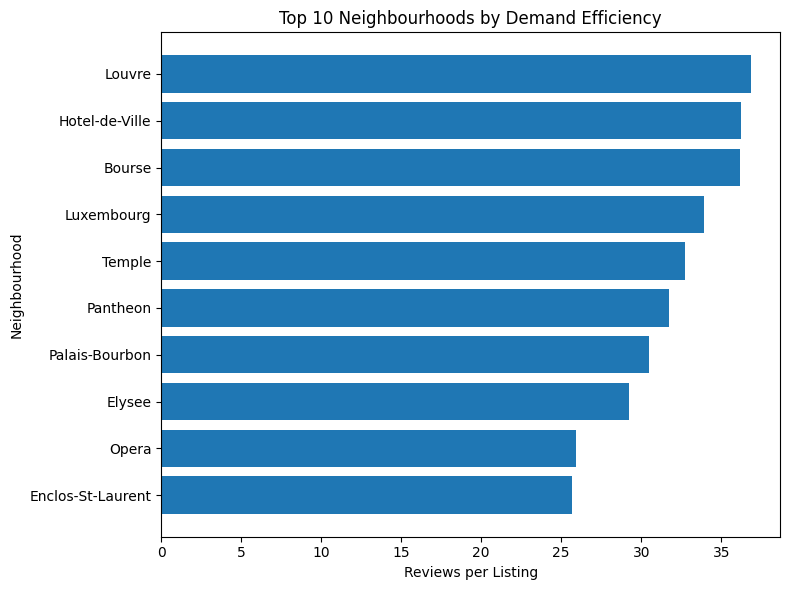

In [216]:
top_eff = demand_supply.sort_values(
    by="reviews_per_listing", ascending=False
)
top10 = top_eff.head(10).sort_values(by="reviews_per_listing")

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.barh(top10["neighbourhood"], top10["reviews_per_listing"])

plt.title("Top 10 Neighbourhoods by Demand Efficiency")
plt.xlabel("Reviews per Listing")
plt.ylabel("Neighbourhood")

plt.tight_layout()
plt.show()

“Areas such as Louvre, Hotel-de-Ville, and Luxembourg demonstrate a strong combination of high pricing and demand efficiency, indicating markets with strong pricing power. However, these markets differ in nature, with some representing high-end, limited-supply segments, while others reflect more active and consistently demanded areas

Locations with high supply , low demand

In [217]:
demand_supply.sort_values(by="reviews_per_listing",ascending=True).head(5)

,neighbourhood,median_price,listings_count,total_reviews,reviews_per_listing
10,Menilmontant,65.0,2326,42549,18.292777
2,Buttes-Chaumont,68.0,2346,43444,18.518329
0,Batignolles-Monceau,84.0,2434,46389,19.058751
3,Buttes-Montmartre,75.0,4527,98209,21.694058
6,Gobelins,75.0,1423,31162,21.898805


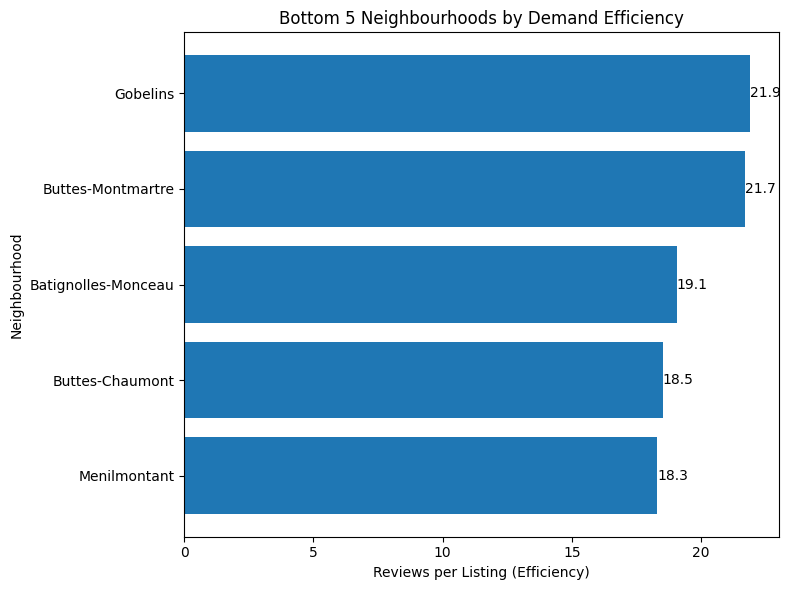

In [218]:
bottom5 = demand_supply.sort_values(
    by="reviews_per_listing", ascending=True
).head(5)

# نرتب عشان الشكل يبقى واضح
bottom5 = bottom5.sort_values(by="reviews_per_listing")

# الرسم
plt.figure(figsize=(8,6))
plt.barh(bottom5["neighbourhood"], bottom5["reviews_per_listing"])

plt.title("Bottom 5 Neighbourhoods by Demand Efficiency")
plt.xlabel("Reviews per Listing (Efficiency)")
plt.ylabel("Neighbourhood")

# إضافة القيم
for i, v in enumerate(bottom5["reviews_per_listing"]):
    plt.text(v, i, f"{v:.1f}", va='center')

plt.tight_layout()
plt.show()

Despite having relatively high listing volumes, these neighbourhoods exhibit low demand efficiency, indicating that demand is diluted across a large number of listings, which reduces the performance of individual properties

In [219]:
# “High supply does not necessarily indicate strong demand. In several neighbourhoods, demand appears inflated due to the large number of listings rather than strong individual performance


Property type Analysis

In [220]:
df["room_type"].value_counts(normalize=True)

room_type
Entire place    0.826253
Private room    0.139994
Hotel room      0.025647
Shared room     0.008106
Name: proportion, dtype: float64

The Paris Airbnb market is heavily dominated by entire homes, indicating a highly competitive environment in this segment

In [221]:
df.groupby("room_type")["number_of_reviews"].sum()

room_type
Entire place    768447
Hotel room       28891
Private room    168371
Shared room       8451
Name: number_of_reviews, dtype: int32

In [222]:
df["base_type"].value_counts(normalize=True).head(10)

base_type
apartment             0.875867
boutique hotel        0.032913
condominium           0.031780
loft                  0.020822
hotel                 0.009864
house                 0.008380
townhouse             0.004571
serviced apartment    0.004239
bed and breakfast     0.003477
hostel                0.002500
Name: proportion, dtype: float64

In [223]:
df.groupby("base_type")["number_of_reviews"].sum().sort_values(ascending=False)

base_type
apartment             829234
loft                   36433
condominium            31226
boutique hotel         26685
bed and breakfast       9000
townhouse               7890
house                   7097
serviced apartment      5590
hostel                  5400
hotel                   4996
guesthouse              4506
guest suite             2017
Boat                     943
Private room             784
Tiny house               522
place                    498
boat                     291
Houseboat                242
tiny house               138
aparthotel               115
Dome house               102
floor                     91
earth house               90
villa                     69
Earth house               46
nature lodge              38
Cave                      30
Campsite                  27
cottage                   25
home/apt                  14
bungalow                   8
Treehouse                  5
chalet                     4
Island                     2
hous

In [224]:
df[["room_type","base_type"]].value_counts(normalize=True).head(10)

room_type     base_type     
Entire place  apartment         0.766481
Private room  apartment         0.103741
Entire place  condominium       0.025510
Hotel room    boutique hotel    0.020764
Entire place  loft              0.018947
Private room  boutique hotel    0.012032
              hotel             0.007286
Entire place  house             0.006309
Private room  condominium       0.005723
Shared room   apartment         0.005645
Name: proportion, dtype: float64

In [225]:
df["base_type"].value_counts().tail(22)

base_type
Houseboat          6
home/apt           4
boat               4
Earth house        3
bungalow           3
nature lodge       2
earth house        2
tiny house         2
chalet             2
cottage            2
Campsite           1
Cave               1
cabin              1
houseboat          1
igloo              1
Treehouse          1
casa particular    1
floor              1
Island             1
Dome house         1
Camper/RV          1
Barn               1
Name: count, dtype: int64

In [226]:
df_grouped = df.groupby(["room_type","base_type"]).agg({
        "price":"median",
    "number_of_reviews": "sum",
    "listing_id": "count"
}).reset_index().rename(columns={
    "number_of_reviews": "total_reviews",
    "listing_id": "listings_count"
})

df_grouped["reviews_per_listing"] = df_grouped["total_reviews"] / df_grouped["listings_count"]

df_grouped[df_grouped["listings_count"]>10].sort_values(by="reviews_per_listing", ascending=False).head(15)


,room_type,base_type,price,total_reviews,listings_count,reviews_per_listing
32,Hotel room,hostel,69.0,3222,35,92.057143
45,Private room,guest suite,55.0,1173,14,83.785714
21,Entire place,guesthouse,92.5,2551,32,79.718750
1,Entire place,Boat,162.5,943,12,78.583333
38,Private room,bed and breakfast,70.0,7859,127,61.881890
54,Private room,townhouse,60.0,3715,73,50.890411
46,Private room,guesthouse,50.0,1954,47,41.574468
20,Entire place,guest suite,76.0,844,21,40.190476
30,Hotel room,bed and breakfast,127.5,887,24,36.958333
63,Shared room,hostel,28.0,1872,52,36.000000


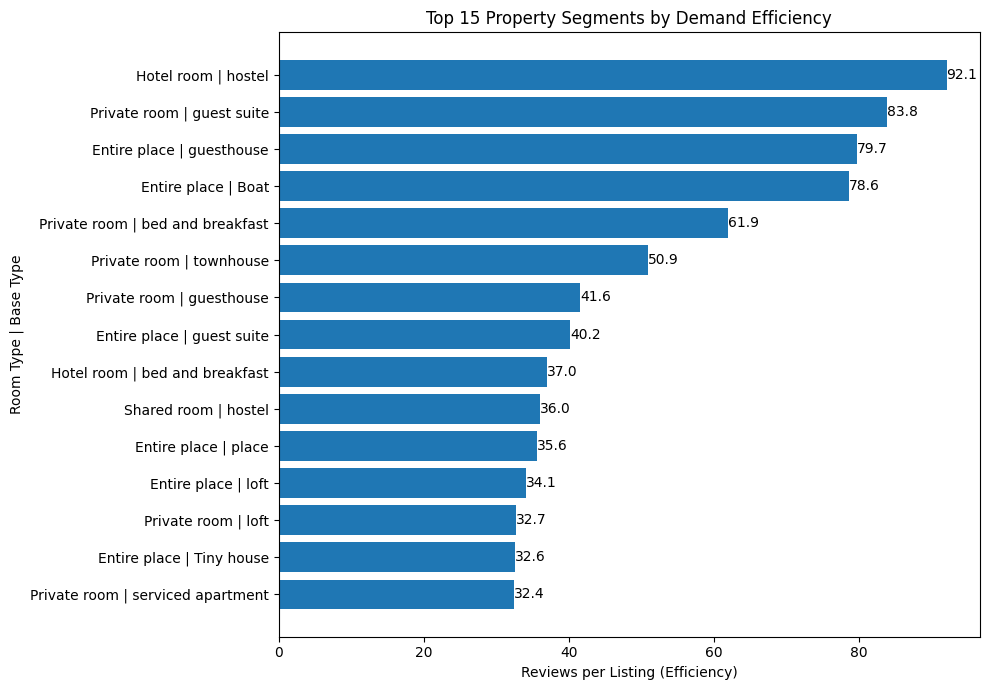

In [227]:

top15 = df_grouped[df_grouped["listings_count"] > 10] \
    .sort_values(by="reviews_per_listing", ascending=False) \
    .head(15)

# نعمل label يجمع room_type + base_type
top15["segment"] = top15["room_type"] + " | " + top15["base_type"]

# نرتب للرسم
top15 = top15.sort_values(by="reviews_per_listing")

# الرسم
plt.figure(figsize=(10,7))
plt.barh(top15["segment"], top15["reviews_per_listing"])

plt.title("Top 15 Property Segments by Demand Efficiency")
plt.xlabel("Reviews per Listing (Efficiency)")
plt.ylabel("Room Type | Base Type")

# أرقام على البار
for i, v in enumerate(top15["reviews_per_listing"]):
    plt.text(v, i, f"{v:.1f}", va='center')

plt.tight_layout()
plt.show()

In [228]:
df_all = df[df["number_of_reviews"]>0].groupby(["neighbourhood","room_type","base_type"]).agg({
        "price":"median",
    "number_of_reviews": "sum",
    "listing_id": "count"
}).reset_index().rename(columns={
    "number_of_reviews": "total_reviews",
    "listing_id": "listings_count"
})
df_all["total_revenue"]=df_all["total_reviews"]*df_all["price"]
df_all["avg_revenue"]=df_all["total_revenue"]/df_all["listings_count"]
df_all["efficiency"] = df_all["total_reviews"] / df_all["listings_count"]
df_all["confidence"] = np.where(
    df_all["listings_count"] >= 15, "High",
    np.where(df_all["listings_count"] >= 5, "Medium", "Low")
)
x=df_all[df_all["listings_count"]>10].sort_values(by="efficiency",ascending=False).head(19)
x.sort_values(by="price",ascending=False).head(10)

,neighbourhood,room_type,base_type,price,total_reviews,listings_count,total_revenue,avg_revenue,efficiency,confidence
110,Elysee,Entire place,loft,190.0,872,17,165680.0,9745.882353,51.294118,High
326,Palais-Bourbon,Entire place,loft,175.5,1018,20,178659.0,8932.950000,50.900000,High
31,Bourse,Entire place,serviced apartment,173.0,574,11,99302.0,9027.454545,52.181818,Medium
214,Louvre,Entire place,loft,160.0,1511,21,241760.0,11512.380952,71.952381,High
463,Temple,Entire place,loft,150.0,4536,71,680400.0,9583.098592,63.887324,High
172,Gobelins,Hotel room,boutique hotel,148.0,729,14,107892.0,7706.571429,52.071429,Medium
281,Observatoire,Hotel room,boutique hotel,148.0,2087,27,308876.0,11439.851852,77.296296,High
30,Bourse,Entire place,loft,141.5,2964,40,419406.0,10485.150000,74.100000,High
303,Opera,Entire place,serviced apartment,133.0,1137,15,151221.0,10081.400000,75.800000,High
148,Enclos-St-Laurent,Private room,boutique hotel,114.5,1237,14,141636.5,10116.892857,88.357143,Medium


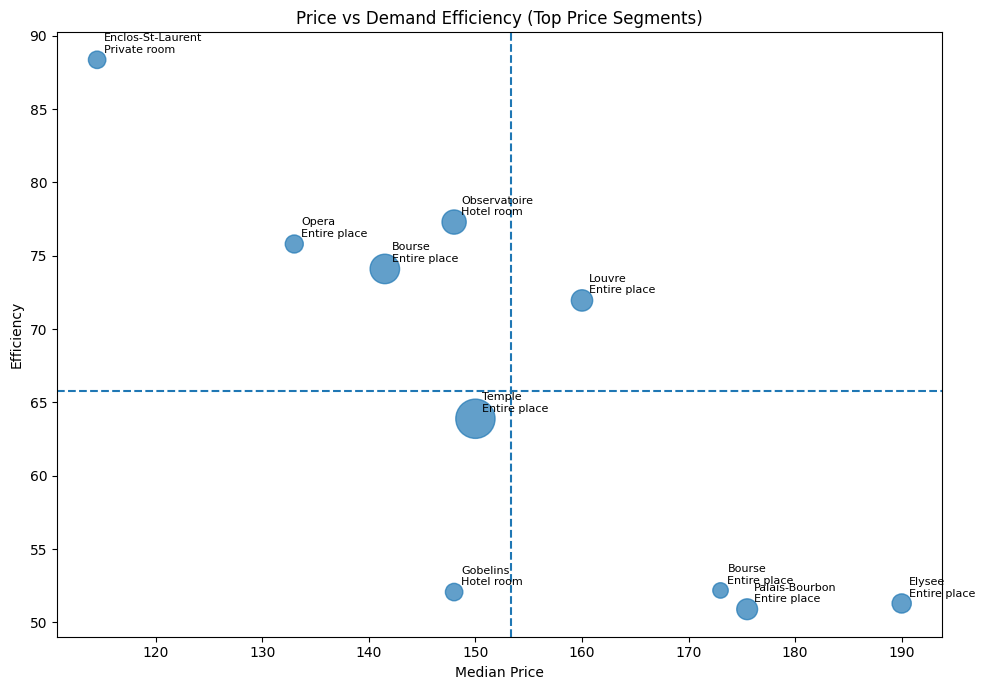

In [229]:

x_top_price = x.sort_values(by="price", ascending=False).head(10).copy()
x_top_price["label"] = x_top_price["neighbourhood"] + "\n" + x_top_price["room_type"]

plt.figure(figsize=(10,7))

# حجم النقاط (normalize عشان مايبقاش مبالغ فيه)
sizes = (x_top_price["listings_count"] / x_top_price["listings_count"].max()) * 800

# الرسم
plt.scatter(
    x_top_price["price"],
    x_top_price["efficiency"],
    s=sizes,
    alpha=0.7
)

# ✨ خطوط المتوسط (quadrants)
plt.axhline(x_top_price["efficiency"].mean(), linestyle='--')
plt.axvline(x_top_price["price"].mean(), linestyle='--')

# ✨ labels بشكل أنضف
for _, row in x_top_price.iterrows():
    plt.annotate(
        row["label"],
        (row["price"], row["efficiency"]),
        xytext=(5,5),
        textcoords="offset points",
        fontsize=8
    )

plt.title("Price vs Demand Efficiency (Top Price Segments)")
plt.xlabel("Median Price")
plt.ylabel("Efficiency")

plt.tight_layout()
plt.show()

In [230]:
print(df_all["listings_count"].describe(),
      df_all["total_reviews"].describe(),
      
      df_all["efficiency"].describe())


count     508.000000
mean       76.602362
std       333.145637
min         1.000000
25%         1.000000
50%         4.000000
75%        15.000000
max      3699.000000
Name: listings_count, dtype: float64 count      508.000000
mean      1917.637795
std       7397.134366
min          1.000000
25%         26.000000
50%        137.000000
75%        518.000000
max      72566.000000
Name: total_reviews, dtype: float64 count    508.000000
mean      40.325793
std       50.983957
min        1.000000
25%       11.000000
50%       25.583333
75%       47.569444
max      516.000000
Name: efficiency, dtype: float64


Market Segmentation

In [231]:
EFF_Q2 = df_all["efficiency"].quantile(0.5)
EFF_Q3 = df_all["efficiency"].quantile(0.75)

DEMAND_Q2 = df_all["total_reviews"].quantile(0.5)
DEMAND_Q3 = df_all["total_reviews"].quantile(0.75)

PRICE_Q2 = df_all["price"].quantile(0.5)
PRICE_Q3 = df_all["price"].quantile(0.75)

SUPPLY_Q2 = df_all["listings_count"].quantile(0.5)
SUPPLY_Q3 = df_all["listings_count"].quantile(0.75)

In [232]:
saturated = df_all[
    (df_all["total_reviews"] >= DEMAND_Q3) &
    (df_all["efficiency"] < EFF_Q2) &
    (df_all["listings_count"] >= SUPPLY_Q3)
]

weak = df_all[
    (df_all["total_reviews"] < DEMAND_Q2) &
    (df_all["efficiency"] < EFF_Q2)
]



In [233]:
min_listings = max(5, int(df_all["listings_count"].quantile(0.50)))  # avoid noise

premium = df_all[
    (df_all["price"] >= PRICE_Q3) &
    (df_all["efficiency"] >= EFF_Q2) &
    (df_all["listings_count"] >= min_listings)
].sort_values(by="avg_revenue", ascending=False)

premium.sort_values(by="efficiency",ascending=False).head(11)

,neighbourhood,room_type,base_type,price,total_reviews,listings_count,total_revenue,avg_revenue,efficiency,confidence
115,Elysee,Hotel room,hotel,144.0,448,5,64512.0,12902.400000,89.600000,Medium
495,Vaugirard,Hotel room,hotel,147.5,475,6,70062.5,11677.083333,79.166667,Medium
281,Observatoire,Hotel room,boutique hotel,148.0,2087,27,308876.0,11439.851852,77.296296,High
30,Bourse,Entire place,loft,141.5,2964,40,419406.0,10485.150000,74.100000,High
214,Louvre,Entire place,loft,160.0,1511,21,241760.0,11512.380952,71.952381,High
463,Temple,Entire place,loft,150.0,4536,71,680400.0,9583.098592,63.887324,High
218,Louvre,Hotel room,serviced apartment,267.0,362,6,96654.0,16109.000000,60.333333,Medium
31,Bourse,Entire place,serviced apartment,173.0,574,11,99302.0,9027.454545,52.181818,Medium
172,Gobelins,Hotel room,boutique hotel,148.0,729,14,107892.0,7706.571429,52.071429,Medium
110,Elysee,Entire place,loft,190.0,872,17,165680.0,9745.882353,51.294118,High


In [234]:
p = premium.copy()

# normalize
p["price_norm"] = p["price"] / p["price"].max()
p["eff_norm"] = p["efficiency"] / p["efficiency"].max()

# score (غيري الأوزان لو عايزة)
p["balance_score"] = (p["eff_norm"] * 0.6) + (p["price_norm"] * 0.4)

best = p.sort_values(by="balance_score", ascending=False)
best.head(10)

,neighbourhood,room_type,base_type,price,total_reviews,listings_count,total_revenue,avg_revenue,efficiency,confidence,price_norm,eff_norm,balance_score
115,Elysee,Hotel room,hotel,144.0,448,5,64512.0,12902.400000,89.600000,Medium,0.411429,1.000000,0.764571
218,Louvre,Hotel room,serviced apartment,267.0,362,6,96654.0,16109.000000,60.333333,Medium,0.762857,0.673363,0.709161
495,Vaugirard,Hotel room,hotel,147.5,475,6,70062.5,11677.083333,79.166667,Medium,0.421429,0.883557,0.698705
281,Observatoire,Hotel room,boutique hotel,148.0,2087,27,308876.0,11439.851852,77.296296,High,0.422857,0.862682,0.686752
214,Louvre,Entire place,loft,160.0,1511,21,241760.0,11512.380952,71.952381,High,0.457143,0.803040,0.664681
30,Bourse,Entire place,loft,141.5,2964,40,419406.0,10485.150000,74.100000,High,0.404286,0.827009,0.657920
332,Palais-Bourbon,Hotel room,serviced apartment,350.0,239,7,83650.0,11950.000000,34.142857,Medium,1.000000,0.381059,0.628635
139,Enclos-St-Laurent,Entire place,townhouse,280.5,272,6,76296.0,12716.000000,45.333333,Medium,0.801429,0.505952,0.624143
463,Temple,Entire place,loft,150.0,4536,71,680400.0,9583.098592,63.887324,High,0.428571,0.713028,0.599245
237,Luxembourg,Entire place,serviced apartment,330.0,217,7,71610.0,10230.000000,31.000000,Medium,0.942857,0.345982,0.584732


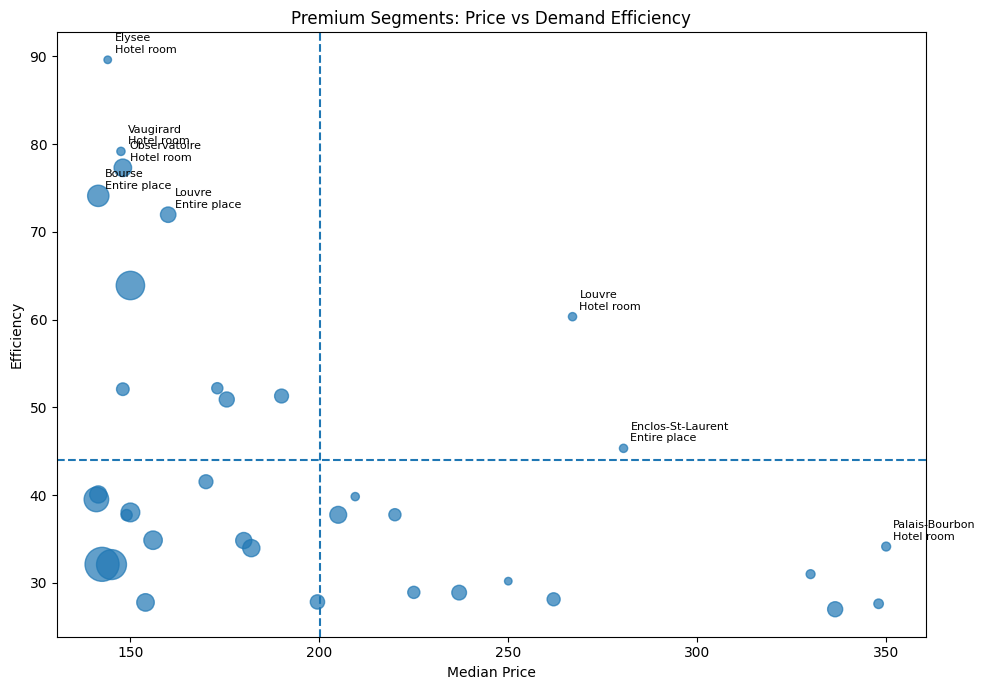

In [235]:

p = premium.copy()

# label بسيط (من غير زحمة)
p["label"] = p["neighbourhood"] + "\n" + p["room_type"]

plt.figure(figsize=(10,7))

# normalize الحجم عشان الشكل يبقى نظيف
sizes = (p["listings_count"] / p["listings_count"].max()) * 600

plt.scatter(
    p["price"],
    p["efficiency"],
    s=sizes,
    alpha=0.7
)

# خطوط المتوسط (reference)
plt.axhline(p["efficiency"].mean(), linestyle='--')
plt.axvline(p["price"].mean(), linestyle='--')

# labels خفيفة (اختياري: أعلى 8 بس)
top_labels = p.head(8)

for _, row in top_labels.iterrows():
    plt.annotate(
        row["label"],
        (row["price"], row["efficiency"]),
        xytext=(5,5),
        textcoords="offset points",
        fontsize=8
    )

plt.title("Premium Segments: Price vs Demand Efficiency")
plt.xlabel("Median Price")
plt.ylabel("Efficiency")

plt.tight_layout()
plt.show()

In [236]:
saturated

,neighbourhood,room_type,base_type,price,total_reviews,listings_count,total_revenue,avg_revenue,efficiency,confidence
1,Batignolles-Monceau,Entire place,apartment,87.0,30838,1942,2682906.0,1381.516993,15.879506,High
2,Batignolles-Monceau,Entire place,condominium,83.0,1304,60,108232.0,1803.866667,21.733333,High
16,Batignolles-Monceau,Private room,hotel,108.0,572,31,61776.0,1992.774194,18.451613,High
47,Buttes-Chaumont,Entire place,apartment,70.0,26799,1692,1875930.0,1108.705674,15.838652,High
49,Buttes-Chaumont,Entire place,condominium,80.0,1648,72,131840.0,1831.111111,22.888889,High
50,Buttes-Chaumont,Entire place,house,150.0,601,30,90150.0,3005.000000,20.033333,High
51,Buttes-Chaumont,Entire place,loft,102.5,1403,62,143807.5,2319.475806,22.629032,High
57,Buttes-Chaumont,Private room,apartment,40.0,8237,350,329480.0,941.371429,23.534286,High
60,Buttes-Chaumont,Private room,condominium,42.0,718,31,30156.0,972.774194,23.161290,High
74,Buttes-Montmartre,Entire place,apartment,79.0,72566,3699,5732714.0,1549.801027,19.617735,High


Capacity Optimization Analysis

In [237]:
df["capacity_band"] = pd.cut(
    df["accommodates"],
    bins=[0,2,4,6,8,20],
    labels=["1-2","3-4","5-6","7-8","9+"]
)


In [238]:
df_capacity = df.groupby(["capacity_band"]).agg({
    "price": "median",
    "number_of_reviews": "sum",
    
    "listing_id": "count"
}).reset_index()
df_capacity["Avg_revenue"]=df_capacity["price"]*df_capacity["number_of_reviews"]/df_capacity["listing_id"]
df_capacity["efficiency"] = df_capacity["number_of_reviews"] / df_capacity["listing_id"]
df_capacity

C:\Users\DELL\AppData\Local\Temp\ipykernel_17872\3855512435.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_capacity = df.groupby(["capacity_band"]).agg({


,capacity_band,price,number_of_reviews,listing_id,Avg_revenue,efficiency
0,1-2,70.0,456162,23718,1346.291424,19.232735
1,3-4,95.0,348433,19878,1665.214559,17.528574
2,5-6,150.0,124327,5926,3146.987850,20.979919
3,7-8,224.5,31316,1182,5947.920474,26.494078
4,9+,420.0,13922,491,11908.839104,28.354379


Larger capacity properties (5+ guests) demonstrate disproportionately higher revenue and demand efficiency despite significantly lower market supply, indicating strong potential for premium positioning and differentiated investment strategy

Features Impact (Amenities + Bedrooms)

In [239]:
from sklearn.preprocessing import MultiLabelBinarizer
import ast

# convert each cell in column into list
df['amenities'] = df['amenities'].apply(ast.literal_eval)

# One-Hot Encode the amenities
# MultiLabelBinarizer converts
# separate binary columns
mlb = MultiLabelBinarizer()
amenities_encoded = pd.DataFrame(
    mlb.fit_transform(df['amenities']),
    columns=mlb.classes_,
    index=df.index
)

# Count how many listings contain each amenity
counts = amenities_encoded.sum(axis=0)
# only amenities that appear in >= 10,000 listings

keep_cols = counts[counts >= 10000].index

amenities_filtered = amenities_encoded[keep_cols]

print("Before:", amenities_encoded.shape)
print("After :", amenities_filtered.shape)



Before: (51195, 627)
After : (51195, 28)


In [240]:
amenities_filtered.head()
popular = amenities_filtered.sum().sort_values(ascending=False)

print(popular)

Wifi                         48759
Heating                      48419
Essentials                   47582
Kitchen                      47116
Washer                       40952
Long term stays allowed      40623
Smoke alarm                  37057
Hair dryer                   36484
Iron                         36235
Hangers                      36005
TV                           34645
Shampoo                      32020
Dedicated workspace          31358
Hot water                    28782
Dishes and silverware        24028
Refrigerator                 22586
Cooking basics               20994
Coffee maker                 19860
Elevator                     19584
Bed linens                   18930
Microwave                    17902
Oven                         17304
Dryer                        16472
Stove                        15942
Cable TV                     12765
Carbon monoxide alarm        12387
Dishwasher                   12238
Paid parking off premises    10468
dtype: int64


Most common amenities

<Axes: >

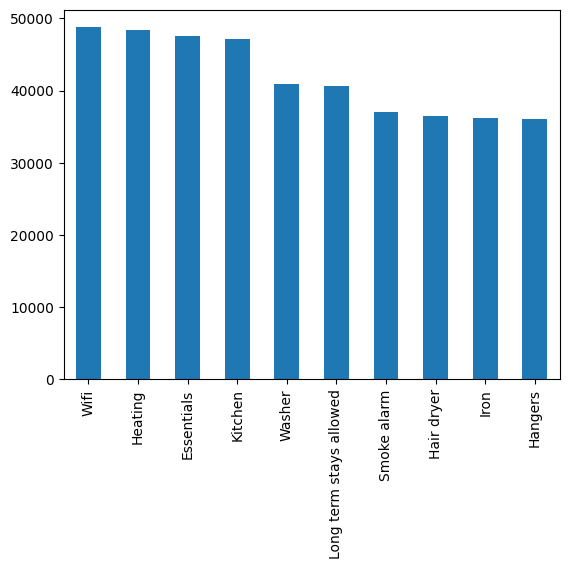

In [241]:
popular.head(10).plot(kind='bar')

In [242]:
df['amenities_count'] = amenities_encoded.sum(axis=1)

df['amenities_count'].describe()

count    51195.000000
mean        18.181209
std          8.292512
min          0.000000
25%         12.000000
50%         17.000000
75%         24.000000
max         78.000000
Name: amenities_count, dtype: float64

In [243]:
df["amenities_count"].value_counts().sort_values(ascending=False).reset_index()

,amenities_count,count
0,12,2771
1,11,2668
2,13,2661
3,14,2566
4,10,2537
5,15,2377
6,9,2322
7,16,2078
8,17,1957
9,21,1906


In [244]:
df[(df["amenities_count"]==0)&(df["price"]>PRICE_Q2)][["neighbourhood","base_type","room_type","price"]]

,neighbourhood,base_type,room_type,price
201019,Buttes-Montmartre,apartment,Private room,600
201173,Luxembourg,apartment,Private room,119
205375,Opera,apartment,Private room,130
232960,Batignolles-Monceau,apartment,Entire place,96
240392,Batignolles-Monceau,apartment,Entire place,120
250607,Passy,apartment,Entire place,300
273188,Vaugirard,apartment,Entire place,165
273297,Vaugirard,apartment,Entire place,240
273372,Passy,apartment,Entire place,100
273655,Popincourt,apartment,Entire place,250


<Axes: >

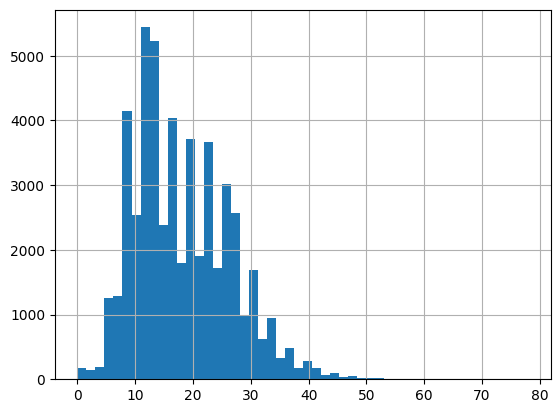

In [245]:
df['amenities_count'].hist(bins=50)

In [246]:
# Most listings in Paris offer between 10 and 25 amenities.

# This represents the competitive market standard.

# Listings with fewer than 10 amenities appear under-equipped.

# Listings with more than 35 amenities are typically positioned as premium.

Relation between amenties and price

<Axes: xlabel='amenities_count'>

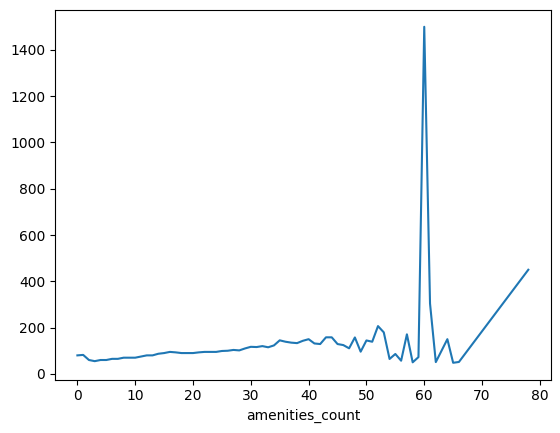

In [247]:
df.groupby('amenities_count')['price'].median().plot()

In [248]:
# Median price increases as the number of amenities increases.

# The effect is clear up to around 30 amenities.

# After that point, the price increase becomes less significant.

In [249]:
amenties_price = []

for col in amenities_filtered.columns:
    
    # median price مع amenity
    price_with = df.loc[amenities_filtered[col] == 1, "price"].median()
    
    # median price بدون amenity
    price_without = df.loc[amenities_filtered[col] == 0, "price"].median()
    
    # الفرق
    diff = price_with - price_without
    
    # نسبة الزيادة %
    if price_without != 0:
        pct_increase = (diff / price_without) * 100
    else:
        pct_increase = 0
    
    amenties_price.append([
        col,
        price_with,
        price_without,
        diff,
        pct_increase
    ])

# نحولها ل DataFrame
amenity_price_impact = pd.DataFrame(
    amenties_price,
    columns=[
        "amenity",
        "median_price_with",
        "median_price_without",
        "price_difference",
        "percentage_increase"
    ]
)

# ترتيب حسب أعلى نسبة زيادة
amenity_price_impact = amenity_price_impact.sort_values(
    by="percentage_increase",
    ascending=False
)

amenity_price_impact.head(10)

,amenity,median_price_with,median_price_without,price_difference,percentage_increase
7,Dishwasher,118.0,80.0,38.0,47.500000
25,TV,99.0,70.0,29.0,41.428571
8,Dryer,109.0,80.0,29.0,36.250000
1,Cable TV,108.0,82.0,26.0,31.707317
27,Wifi,90.0,70.0,20.0,28.571429
11,Hair dryer,95.0,75.0,20.0,26.666667
15,Iron,95.0,75.0,20.0,26.666667
3,Coffee maker,100.0,80.0,20.0,25.000000
19,Oven,100.0,80.0,20.0,25.000000
18,Microwave,100.0,81.0,19.0,23.456790


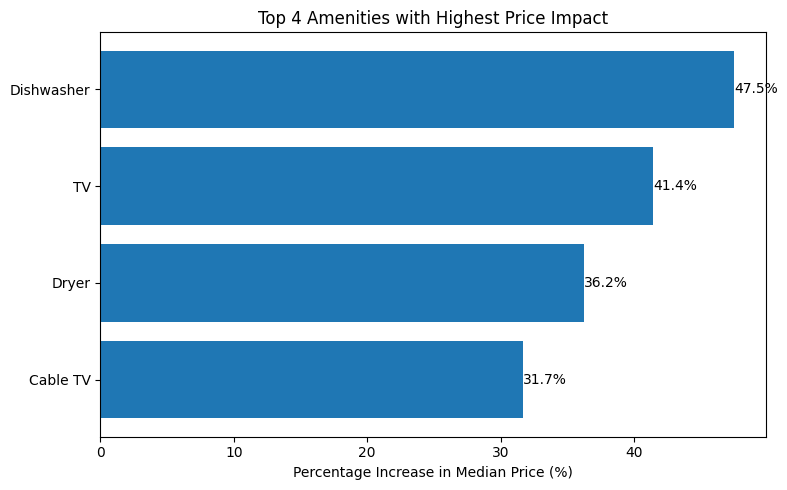

In [250]:
top4 = amenity_price_impact.head(4).sort_values(
    by="percentage_increase"
)

plt.figure(figsize=(8,5))

plt.barh(
    top4["amenity"],
    top4["percentage_increase"]
)

plt.xlabel("Percentage Increase in Median Price (%)")
plt.title("Top 4 Amenities with Highest Price Impact")

# كتابة القيم جنب كل bar
for i, v in enumerate(top4["percentage_increase"]):
    plt.text(v, i, f"{v:.1f}%", va='center')

plt.tight_layout()
plt.show()

In [251]:
amenities_demand = []

for col in amenities_filtered.columns:
    
    count_with = amenities_filtered[col].sum()
    
    # نفلتر هنا 👇
    if count_with > 6:
        
        # median demand مع amenity
        demand_with = df.loc[amenities_filtered[col] == 1, "number_of_reviews"].median()
        
        # median demand بدون amenity
        demand_without = df.loc[amenities_filtered[col] == 0, "number_of_reviews"].median()
        
        # الفرق
        diff = demand_with - demand_without
        
        # نسبة الزيادة %
        if demand_without != 0:
            pct_increase = (diff / demand_without) * 100
        else:
            pct_increase = 0
        
        amenities_demand.append([
            col,
            demand_with,
            demand_without,
            diff,
            pct_increase,
            count_with
        ])

amenity_demand_impact = pd.DataFrame(
    amenities_demand,
    columns=[
        "amenity",
        "median_demand_with",
        "median_demand_without",
        "demand_difference",
        "percentage_increase",
        "listings_count_with"
    ]
)

# ترتيب حسب أعلى تأثير على الطلب
amenity_demand_impact = amenity_demand_impact.sort_values(
    by="percentage_increase",
    ascending=False
)

amenity_demand_impact.head(10)

,amenity,median_demand_with,median_demand_without,demand_difference,percentage_increase,listings_count_with
3,Coffee maker,13.0,2.0,11.0,550.000000,19860
21,Refrigerator,12.0,2.0,10.0,500.000000,22586
4,Cooking basics,12.0,2.0,10.0,500.000000,20994
6,Dishes and silverware,12.0,2.0,10.0,500.000000,24028
20,Paid parking off premises,17.0,3.0,14.0,466.666667,10468
14,Hot water,10.0,2.0,8.0,400.000000,28782
10,Essentials,5.0,1.0,4.0,400.000000,47582
16,Kitchen,5.0,1.0,4.0,400.000000,47116
13,Heating,5.0,1.0,4.0,400.000000,48419
27,Wifi,5.0,1.0,4.0,400.000000,48759


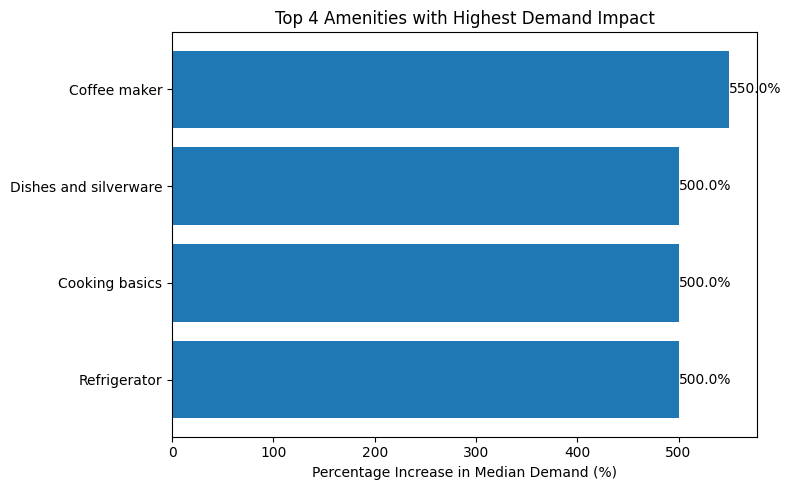

In [252]:
top4_demand = amenity_demand_impact.head(4).sort_values(
    by="percentage_increase"
)

plt.figure(figsize=(8,5))

plt.barh(
    top4_demand["amenity"],
    top4_demand["percentage_increase"]
)

plt.xlabel("Percentage Increase in Median Demand (%)")
plt.title("Top 4 Amenities with Highest Demand Impact")

# إضافة القيم على الرسم
for i, v in enumerate(top4_demand["percentage_increase"]):
    plt.text(v, i, f"{v:.1f}%", va='center')

plt.tight_layout()
plt.show()

In [253]:
# Kitchen-related amenities significantly increase demand.
# Listings lacking these essentials experience noticeably lower booking activity

Relation between count of amenities and demand

<Axes: xlabel='amenities_count'>

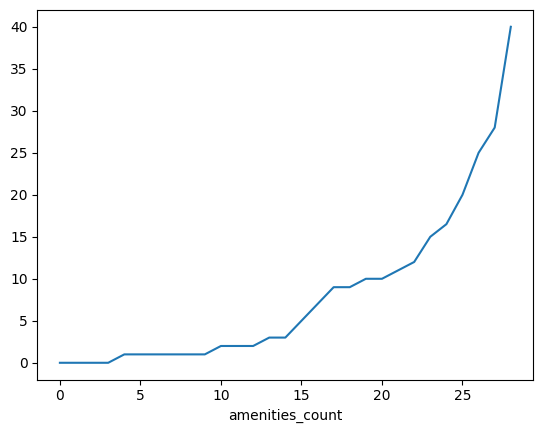

In [254]:
df['amenities_count'] = amenities_filtered.sum(axis=1)

df.groupby('amenities_count')['number_of_reviews'].median().plot()

In [255]:
# Listings with more amenities tend to receive more reviews.

# Better-equipped properties attract stronger demand

In [256]:
# strong core amenity package (Kitchen, Essentials, Wifi) is mandatory.
# Adding comfort features increases pricing potential.
# Over-investing in excessive amenities does not proportionally increase returns.

In [261]:
results = []

total_listings = df.shape[0]

for col in amenities_filtered.columns:
    
    count_with = amenities_filtered[col].sum()
    
    if count_with > 4:
        
        # subsets
        with_am = df.loc[amenities_filtered[col] == 1]
        without_am = df.loc[amenities_filtered[col] == 0]
        
        # price
        price_with = with_am["price"].median()
        price_without = without_am["price"].median()
        
        # demand
        demand_with = with_am["number_of_reviews"].median()
        demand_without = without_am["number_of_reviews"].median()
        
        # revenue proxy
        revenue_with = (with_am["price"] * with_am["number_of_reviews"]).median()
        revenue_without = (without_am["price"] * without_am["number_of_reviews"]).median()
        
        # lifts
        price_lift = ((price_with - price_without) / price_without) * 100 if price_without != 0 else 0
        demand_lift = ((demand_with - demand_without) / demand_without) * 100 if demand_without != 0 else 0
        revenue_lift = ((revenue_with - revenue_without) / revenue_without) * 100 if revenue_without != 0 else 0
        
        penetration = (count_with / total_listings) * 100
        
        results.append([
            col,
            price_lift,
            demand_lift,
            revenue_lift,
            penetration
        ])

amenity_strategy = pd.DataFrame(
    results,
    columns=[
        "amenity",
        "price_lift_%",
        "demand_lift_%",
        "revenue_lift_%",
        "market_penetration_%"
    ]
)

amenity_strategy = amenity_strategy.sort_values(
    by="revenue_lift_%", ascending=False
)

amenity_strategy.head(15)

,amenity,price_lift_%,demand_lift_%,revenue_lift_%,market_penetration_%
6,Dishes and silverware,18.750000,500.000000,700.000000,46.934271
3,Coffee maker,25.000000,550.000000,676.470588,38.792851
21,Refrigerator,18.750000,500.000000,670.666667,44.117590
14,Hot water,9.756098,400.000000,650.000000,56.220334
24,Stove,15.294118,366.666667,606.250000,31.139760
4,Cooking basics,11.764706,500.000000,564.825581,41.007911
20,Paid parking off premises,13.953488,466.666667,490.370370,20.447309
18,Microwave,23.456790,300.000000,488.235294,34.968259
13,Heating,9.756098,400.000000,450.000000,94.577595
19,Oven,25.000000,266.666667,423.809524,33.800176
